# Import and inputs

In [1]:
# Imports and setup
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

import pandas as pd

repo_root = str(Path("..").resolve())
case_study_root = str(Path(".").resolve())
for path in (repo_root, case_study_root):
    if path not in sys.path:
        sys.path.insert(0, path)

# Notebook-specific imports
import re

from merge_formula import nominal_merge_formula, verbal_merge_formula
from SynFlow.Explorer import (
    build_sfiller_df,
    compute_saturating_support_from_sfiller_df,
    merge_sfiller_df_columns,
    spath_explorer,
    spaths_json_to_slotfiller_df,
    rel_explorer,
)
from SynFlow.Explorer.sfiller_df import get_all_slots
from SynFlow.SCD import (
    compute_consecutive_dist_df,
    compute_weighted_consecutive_dist_df,
    count_keyword_tokens_by_period,
    compute_period_period_dist,
    freq_all_slots_by_period,
    multiply_consecutive_dist_saturating_support,
    permutation_test_consecutive_dist,
    plot_all_dists_by_period,
    plot_freq_top_union_slots_by_period,
    plot_period_period_dist,
    plot_permutation_test_consecutive_dist,
    summarize_fdr_correction,
)

In [2]:
# Specify required input

# Input target
target_lemma = "viral"
target_pos = "ADJ"

# Period and regex pattern of the SynFlow parsed file
period = "1995-2025"
corpus_pattern = re.compile(
    r"([^\t]+)\t"      # word form
    r"([^\t]+)\t"      # lemma
    r"([^\t]+)\t"      # POS (UPOS or XPOS)
    r"([^\t]+)\t"      # ID
    r"([^\t]+)\t"      # HEAD
    r"([^\t]+)\t"      # DEPREL
    r"([^\t]+)"        # FEATS
)

# Specify corpus and output folders
corpus_folder = f"/home/volt/bach/Corpora/deu_news_1995-2025_sentences_parsed"
output_folder = Path(".").resolve()

# The path to the slot count JSON file
slot_json_path = f"output/{target_lemma}_{target_pos}_{period}/Explorer/{target_lemma}_{target_pos}_spaths.json"


In [3]:
# Dont change below this line
output_folder_lemma = output_folder / "output" / f"{target_lemma}_{target_pos}_{period}"
output_explorer = f"{output_folder_lemma}/Explorer"
output_embedding = f"{output_folder_lemma}/Embedding"
input_SCD = output_folder / "input" /f"{target_lemma}_{target_pos}_{period}" / "SCD"
output_SCD = output_folder / "output" /f"{target_lemma}_{target_pos}_{period}" / "SCD"

os.makedirs(output_explorer, exist_ok=True)
os.makedirs(output_embedding, exist_ok=True)
os.makedirs(input_SCD, exist_ok=True)
os.makedirs(output_SCD, exist_ok=True)

# Explore the distribution of the slots

## Slot Frequencies

[1995-2000] Collected 58 context links, 9 distinct arguments.


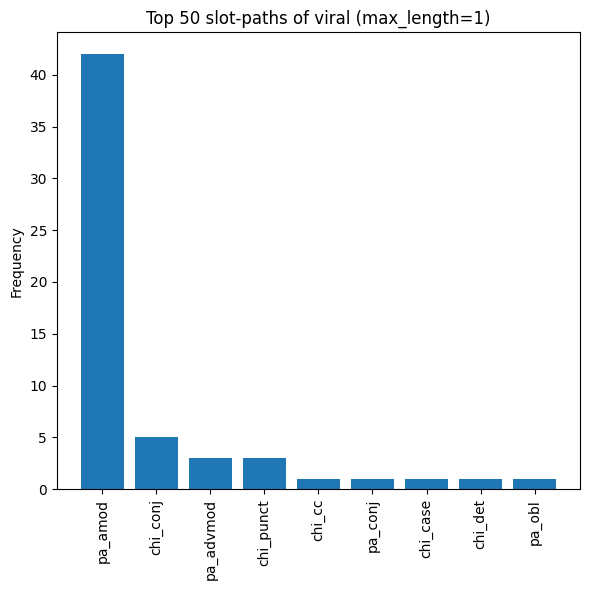

[2001-2005] Collected 35 context links, 6 distinct arguments.


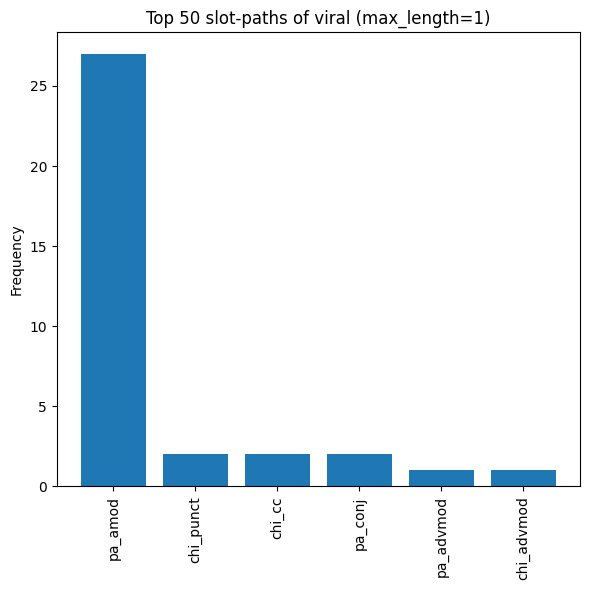

[2006-2010] Collected 116 context links, 6 distinct arguments.


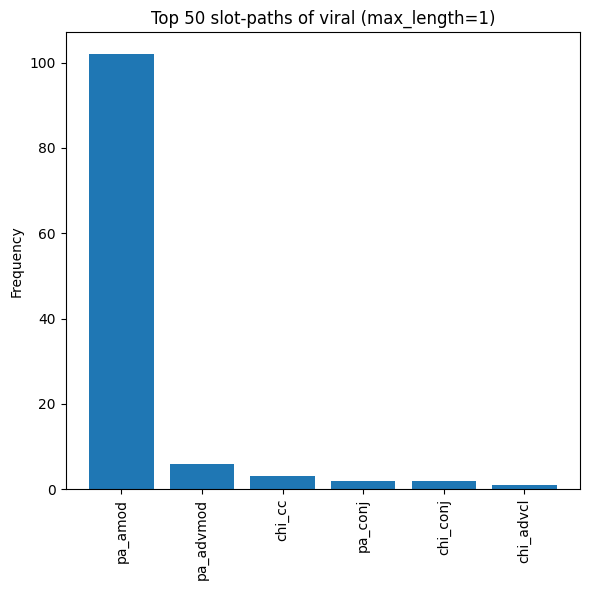

[2011-2015] Collected 214 context links, 15 distinct arguments.


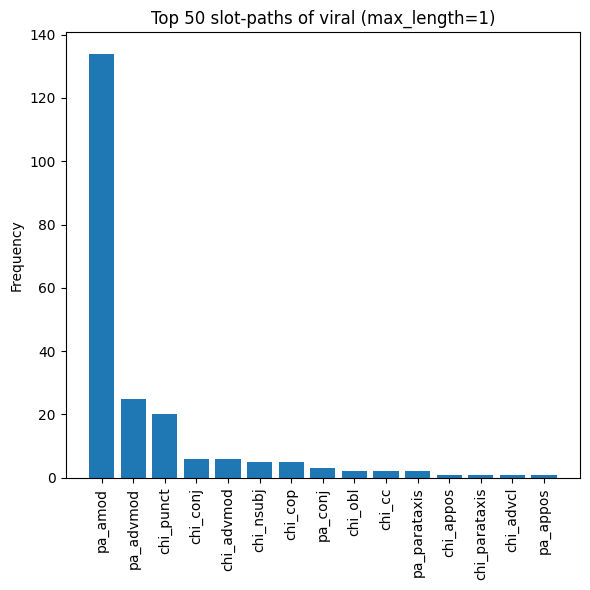

[2016-2020] Collected 296 context links, 11 distinct arguments.


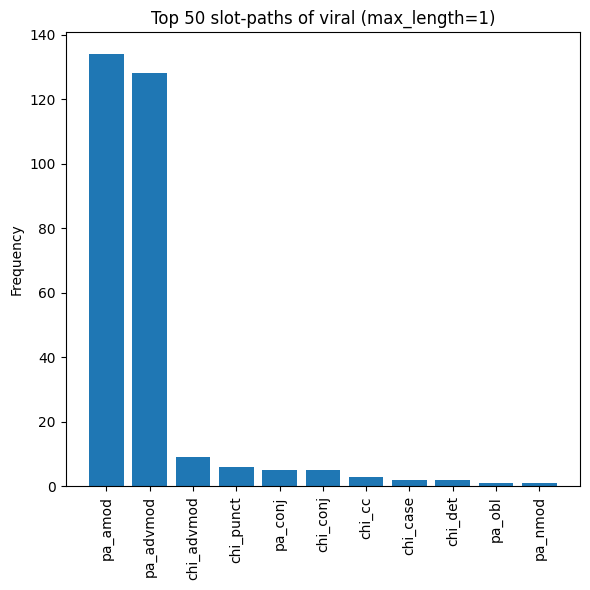

[2021-2025] Collected 632 context links, 16 distinct arguments.


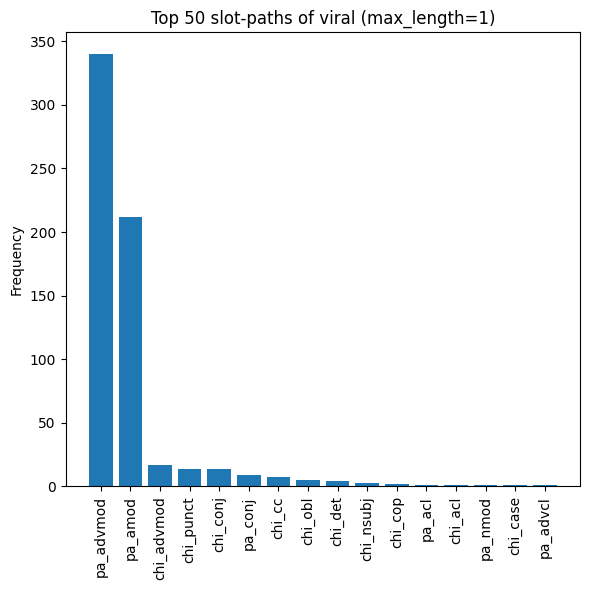

Saved slot-path frequencies to: output/viral_ADJ_1995-2025/Explorer/viral_ADJ_spaths.json


In [4]:
dist = spath_explorer(
    corpus_folder=corpus_folder,
    target_lemma=target_lemma,
    target_pos=target_pos,
    max_length=1,
    top_n=50,
    pattern=corpus_pattern,
    output_folder=output_explorer
)

In [5]:
# Token counts for normalisation
token_counts = count_keyword_tokens_by_period(corpus_folder, target_lemma, target_pos,
                                              max_workers=64)
print(token_counts)


{'1995-2000': 70, '2001-2005': 62, '2006-2010': 155, '2011-2015': 193, '2016-2020': 311, '2021-2025': 627}


In [6]:
plot_freq_top_union_slots_by_period(
    json_path=slot_json_path,
    top_n=10,
    normalized=True,
    relative=False,
    token_counts=token_counts,
)


In [7]:
slot_raw_freq_df = freq_all_slots_by_period(json_path=slot_json_path).T
slot_raw_freq_df.head(30)

,1995-2000,2001-2005,2006-2010,2011-2015,2016-2020,2021-2025
pa_amod,42.0,27.0,102.0,134.0,134.0,212.0
chi_conj,5.0,0.0,2.0,6.0,5.0,14.0
pa_advmod,3.0,1.0,6.0,25.0,128.0,340.0
chi_punct,3.0,2.0,0.0,20.0,6.0,14.0
chi_cc,1.0,2.0,3.0,2.0,3.0,7.0
pa_conj,1.0,2.0,2.0,3.0,5.0,9.0
chi_case,1.0,0.0,0.0,0.0,2.0,1.0
chi_det,1.0,0.0,0.0,0.0,2.0,4.0
pa_obl,1.0,0.0,0.0,0.0,1.0,0.0
chi_advmod,0.0,1.0,0.0,6.0,9.0,17.0


## Rel Explorer
* You can explore what the slots mean here

In [8]:

rel_single_path_results = rel_explorer(
    corpus_folder=corpus_folder,
    pattern=corpus_pattern,
    target_lemma=target_lemma,
    target_pos=target_pos,
    deprel="> (chi_det, [])",
    filler_format="lemma/deprel", # lemma_only, lemma/pos, lemma/deprel, token_only, token/pos, token/deprel
    # Single-path searches always use open matching.
)

rel_single_path_results


,sentence_id,sentence,sfillers,path
0,1998_776908,Es besteht aus einem viralen und einem zellulä...,[ein/chi_det],chi_det
1,2019_910226,Vor Kurzem wurden Reddit - User in einem viral...,[ein/chi_det],chi_det
2,2020_329993,"Die Forscher glauben , dass ihre Folgen für di...",[der/chi_det],chi_det
3,2021_884361,Unter anderem war diese Woche ein viral gegang...,[ein/chi_det],chi_det
4,2022_969975,""" Witcher "" - Schauspieler Henry Cavill mit de...",[sein/chi_det],chi_det
5,2024_283936,"Der Wirt des BULLDOGWirt in Straden , Österrei...",[sein/chi_det],chi_det
6,2024_448027,Eines der viral zeigt die Hauptdarstellerin ( ...,[der/chi_det],chi_det


In [9]:
out_path = f"{output_explorer}/rel_1_path_explorer.tsv"
rel_single_path_results.to_csv(out_path, sep="\t", index=False)


# Build slot_type df of all slots

In [10]:
slot_type_df = spaths_json_to_slotfiller_df(json_path=slot_json_path,
                                    #    exclude=["chi_punct", "chi_det", "chi_case"]
                                       )

print(slot_type_df.head(10))
slot_type_df.to_csv(f"{input_SCD}/{target_lemma}_{target_pos}_slot_type_df.csv", index=False)

             id  subfolder          target          type
0   1995-2000_1  1995-2000  [(viral_ADJ,)]  [(pa_amod,)]
1   1995-2000_2  1995-2000  [(viral_ADJ,)]  [(pa_amod,)]
2   1995-2000_3  1995-2000  [(viral_ADJ,)]  [(pa_amod,)]
3   1995-2000_4  1995-2000  [(viral_ADJ,)]  [(pa_amod,)]
4   1995-2000_5  1995-2000  [(viral_ADJ,)]  [(pa_amod,)]
5   1995-2000_6  1995-2000  [(viral_ADJ,)]  [(pa_amod,)]
6   1995-2000_7  1995-2000  [(viral_ADJ,)]  [(pa_amod,)]
7   1995-2000_8  1995-2000  [(viral_ADJ,)]  [(pa_amod,)]
8   1995-2000_9  1995-2000  [(viral_ADJ,)]  [(pa_amod,)]
9  1995-2000_10  1995-2000  [(viral_ADJ,)]  [(pa_amod,)]


# Build sfiller_df of all slots

In [11]:
# Get all slots in the corect format
all_slots = get_all_slots(slot_raw_freq_df)
print(all_slots)


[pa_amod][chi_conj][pa_advmod][chi_punct][chi_cc][pa_conj][chi_case][chi_det][pa_obl][chi_advmod][chi_advcl][chi_nsubj][chi_cop][chi_obl][pa_parataxis][chi_appos][chi_parataxis][pa_appos][pa_nmod][pa_acl][chi_acl][pa_advcl]


In [12]:
# Building a slot filler df

sfiller_df, dropped_list = build_sfiller_df(
    corpus_folder=corpus_folder,
    template=all_slots, 
    target_lemma=target_lemma,
    target_pos=target_pos,
    pattern=corpus_pattern,
    filtered_pos=[],
    filler_format="token_only", # lemma_only, lemma/deprel, lemma/pos, token_only, token/deprel, token/pos
)


Skipped non-subfolder entries: ['/home/volt/bach/Corpora/deu_news_1995-2025_sentences_parsed/unify_viral.ipynb']


In [13]:
sfiller_df

,subfolder,target,pa_amod,chi_conj,pa_advmod,chi_punct,chi_cc,pa_conj,chi_case,chi_det,...,chi_cop,chi_obl,pa_parataxis,chi_appos,chi_parataxis,pa_appos,pa_nmod,pa_acl,chi_acl,pa_advcl
id,,,,,,,,,,,,,,,,,,,,,
viral/deu_news_1995_1M-sentences.txt/3589715,1995-2000,"[(viral/ADJ,)]","[(Gen,)]",[],[],[],[],[],[],[],...,[],[],[],[],[],[],[],[],[],[]
viral/deu_news_1995_1M-sentences.txt/5615020,1995-2000,"[(viral/ADJ,)]","[(Pyrogene,)]","[(bakterieller,)]",[],[],[],[],[],[],...,[],[],[],[],[],[],[],[],[],[]
viral/deu_news_1995_1M-sentences.txt/8050421,1995-2000,"[(viral/ADJ,)]","[(Systeme,)]","[(viroide,)]",[],[],[],[],[],[],...,[],[],[],[],[],[],[],[],[],[]
viral/deu_news_1995_1M-sentences.txt/9954933,1995-2000,"[(viral/ADJ,)]","[(Gentransfers,)]",[],[],[],[],[],[],[],...,[],[],[],[],[],[],[],[],[],[]
viral/deu_news_1995_1M-sentences.txt/10697085,1995-2000,"[(viral/ADJ,)]","[(Infektionen,)]",[],[],[],[],[],[],[],...,[],[],[],[],[],[],[],[],[],[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
viral/deu_news_2025_1M-sentences.txt/19016065,2021-2025,"[(viral/ADJ,)]","[(Reddit,)]",[],[],[],[],[],[],[],...,[],[],[],[],[],[],[],[],[],[]
viral/deu_news_2025_1M-sentences.txt/19203687,2021-2025,"[(viral/ADJ,)]",[],[],"[(gehen,)]",[],[],[],[],[],...,[],[],[],[],[],[],[],[],[],[]
viral/deu_news_2025_1M-sentences.txt/19395831,2021-2025,"[(viral/ADJ,)]",[],[],"[(machen,)]",[],[],[],[],[],...,[],[],[],[],[],[],[],[],[],[]


In [13]:
def lowercase_slot_fillers(df: pd.DataFrame) -> pd.DataFrame:
    """Lowercase all string elements inside tuple-valued slot-filler columns."""
    df = df.copy()

    metadata_cols = {"id", "subfolder", "target"}
    slot_filler_cols = [col for col in df.columns if col not in metadata_cols]

    def lowercase_item(item):
        if isinstance(item, tuple):
            return tuple(element.lower() if isinstance(element, str) else element for element in item)
        if isinstance(item, str):
            return (item.lower(),)
        return item

    for col in slot_filler_cols:
        df[col] = df[col].apply(
            lambda values: [lowercase_item(item) for item in values]
            if isinstance(values, list)
            else values
        )

    return df

sfiller_df = lowercase_slot_fillers(sfiller_df)

In [14]:
dropped_list

[]

In [14]:
# Save to csv, remember to add the filler format to the name
all_sfiller_csv_path = f"{input_SCD}/{target_lemma}_{target_pos}_sfiller_df_token_only_all.csv"
sfiller_df.to_csv(all_sfiller_csv_path)

## Merging slot types

In [15]:
input_path = f"{input_SCD}/{target_lemma}_{target_pos}_sfiller_df_token_only_all.csv"
output_path = f"{input_SCD}/{target_lemma}_{target_pos}_sfiller_df_token_only_merged.csv"


In [ ]:
merged_df = merge_sfiller_df_columns(
    sfiller_df_path=input_path,
    merge_formula=nominal_merge_formula,
    output_path=output_path,
)

# Calculate (weighted) distance of slot/slot-filler distributions

In [32]:
sfiller_df_path = f"{input_SCD}/{target_lemma}_{target_pos}_sfiller_df_token_only_all.csv"
# sfiller_df_path = f"{input_SCD}/{target_lemma}_{target_pos}_slot_type_df.csv"
sfiller_df = pd.read_csv(sfiller_df_path)


## Compute raw distance

In [33]:
consecutive_dist = compute_consecutive_dist_df(
    sfiller_df=sfiller_df,
    period_col="subfolder",
    min_freq=1,
    mode="data_only",  # "all" or "data_only" if you want to skip empty periods
    measure="tvd"
)
consecutive_dist


,slot,period_1,period_2,measure,dist
0,pa_amod,1995-2000,2001-2005,tvd,0.867725
1,pa_amod,2001-2005,2006-2010,tvd,0.764706
2,pa_amod,2006-2010,2011-2015,tvd,0.701932
3,pa_amod,2011-2015,2016-2020,tvd,0.701493
4,pa_amod,2016-2020,2021-2025,tvd,0.697832
5,chi_conj,1995-2000,2006-2010,tvd,0.800000
6,chi_conj,2006-2010,2011-2015,tvd,1.000000
7,chi_conj,2011-2015,2016-2020,tvd,1.000000
8,chi_conj,2016-2020,2021-2025,tvd,0.928571
9,pa_advmod,1995-2000,2001-2005,tvd,1.000000


## Compute support for the slot distance

In [34]:
saturating_support = compute_saturating_support_from_sfiller_df(
    sfiller_df=sfiller_df,
    period_col="subfolder",
    min_freq=1,
    mode="data_only", # "all" or "data_only" if you want to skip empty periods
    k=100,
)

saturating_support


,slot,period_1,period_2,support_count,support_weight
0,pa_amod,1995-2000,2001-2005,27.0,0.27
1,pa_amod,2001-2005,2006-2010,27.0,0.27
2,pa_amod,2006-2010,2011-2015,102.0,1.00
3,pa_amod,2011-2015,2016-2020,134.0,1.00
4,pa_amod,2016-2020,2021-2025,134.0,1.00
5,chi_conj,1995-2000,2006-2010,2.0,0.02
6,chi_conj,2006-2010,2011-2015,2.0,0.02
7,chi_conj,2011-2015,2016-2020,5.0,0.05
8,chi_conj,2016-2020,2021-2025,5.0,0.05
9,pa_advmod,1995-2000,2001-2005,1.0,0.01


## Compute weighted distance (raw distance x support)

In [35]:

weighted_consecutive_dist = multiply_consecutive_dist_saturating_support(
    consecutive_dist_df=consecutive_dist,
    saturating_support=saturating_support,
)
weighted_consecutive_dist


,slot,period_1,period_2,measure,dist,support_count,support_weight,weighted_dist
0,pa_amod,1995-2000,2001-2005,tvd,0.867725,27.0,0.27,0.234286
1,pa_amod,2001-2005,2006-2010,tvd,0.764706,27.0,0.27,0.206471
2,pa_amod,2006-2010,2011-2015,tvd,0.701932,102.0,1.00,0.701932
3,pa_amod,2011-2015,2016-2020,tvd,0.701493,134.0,1.00,0.701493
4,pa_amod,2016-2020,2021-2025,tvd,0.697832,134.0,1.00,0.697832
5,chi_conj,1995-2000,2006-2010,tvd,0.800000,2.0,0.02,0.016000
6,chi_conj,2006-2010,2011-2015,tvd,1.000000,2.0,0.02,0.020000
7,chi_conj,2011-2015,2016-2020,tvd,1.000000,5.0,0.05,0.050000
8,chi_conj,2016-2020,2021-2025,tvd,0.928571,5.0,0.05,0.046429
9,pa_advmod,1995-2000,2001-2005,tvd,1.000000,1.0,0.01,0.010000


In [36]:
# Combined function

weighted_consecutive_dist = compute_weighted_consecutive_dist_df(
    sfiller_df=sfiller_df,
    period_col="subfolder",
    min_freq=1,
    mode="data_only", # "all" or "data_only" if you want to skip empty periods
    k=100,
    measure="tvd"
)
weighted_consecutive_dist


,slot,period_1,period_2,measure,dist,support_count,support_weight,weighted_dist
0,pa_amod,1995-2000,2001-2005,tvd,0.867725,27.0,0.27,0.234286
1,pa_amod,2001-2005,2006-2010,tvd,0.764706,27.0,0.27,0.206471
2,pa_amod,2006-2010,2011-2015,tvd,0.701932,102.0,1.00,0.701932
3,pa_amod,2011-2015,2016-2020,tvd,0.701493,134.0,1.00,0.701493
4,pa_amod,2016-2020,2021-2025,tvd,0.697832,134.0,1.00,0.697832
5,chi_conj,1995-2000,2006-2010,tvd,0.800000,2.0,0.02,0.016000
6,chi_conj,2006-2010,2011-2015,tvd,1.000000,2.0,0.02,0.020000
7,chi_conj,2011-2015,2016-2020,tvd,1.000000,5.0,0.05,0.050000
8,chi_conj,2016-2020,2021-2025,tvd,0.928571,5.0,0.05,0.046429
9,pa_advmod,1995-2000,2001-2005,tvd,1.000000,1.0,0.01,0.010000


## Permutation test

In [37]:
perm_result_df = permutation_test_consecutive_dist(
    sfiller_df=sfiller_df,
    period_col="subfolder",
    n_permutations=1000,
    min_freq=1,
    k=100,
    weighting=True,
    seed=42,
    num_processes=100,
    chunk_size=10,
    measure="tvd"
)

Permutation testing for pair 1/5: 1995-2000 -> 2001-2005
Permutation testing for pair 2/5: 2001-2005 -> 2006-2010
Permutation testing for pair 3/5: 2006-2010 -> 2011-2015
Permutation testing for pair 4/5: 2011-2015 -> 2016-2020
Permutation testing for pair 5/5: 2016-2020 -> 2021-2025


In [38]:
# perm_result_df_path = f"{output_SCD}/{target_lemma}_{target_pos}_slot_type_perm_result_df.csv"
perm_result_df_path = f"{output_SCD}/{target_lemma}_{target_pos}_sfiller_perm_result_df.csv"

In [39]:
print(perm_result_df)
perm_result_df.to_csv(perm_result_df_path)

          slot   period_1   period_2 measure     statistic  weighting  \
0      pa_amod  1995-2000  2001-2005     tvd  weighted_tvd       True   
1    pa_advmod  1995-2000  2001-2005     tvd  weighted_tvd       True   
2    chi_punct  1995-2000  2001-2005     tvd  weighted_tvd       True   
3       chi_cc  1995-2000  2001-2005     tvd  weighted_tvd       True   
4      pa_conj  1995-2000  2001-2005     tvd  weighted_tvd       True   
5      pa_amod  2001-2005  2006-2010     tvd  weighted_tvd       True   
6    pa_advmod  2001-2005  2006-2010     tvd  weighted_tvd       True   
7       chi_cc  2001-2005  2006-2010     tvd  weighted_tvd       True   
8      pa_conj  2001-2005  2006-2010     tvd  weighted_tvd       True   
9      pa_amod  2006-2010  2011-2015     tvd  weighted_tvd       True   
10    chi_conj  2006-2010  2011-2015     tvd  weighted_tvd       True   
11   pa_advmod  2006-2010  2011-2015     tvd  weighted_tvd       True   
12      chi_cc  2006-2010  2011-2015     tvd  weigh

In [40]:
perm_result_df=pd.read_csv(perm_result_df_path)

## Plot permutation tests

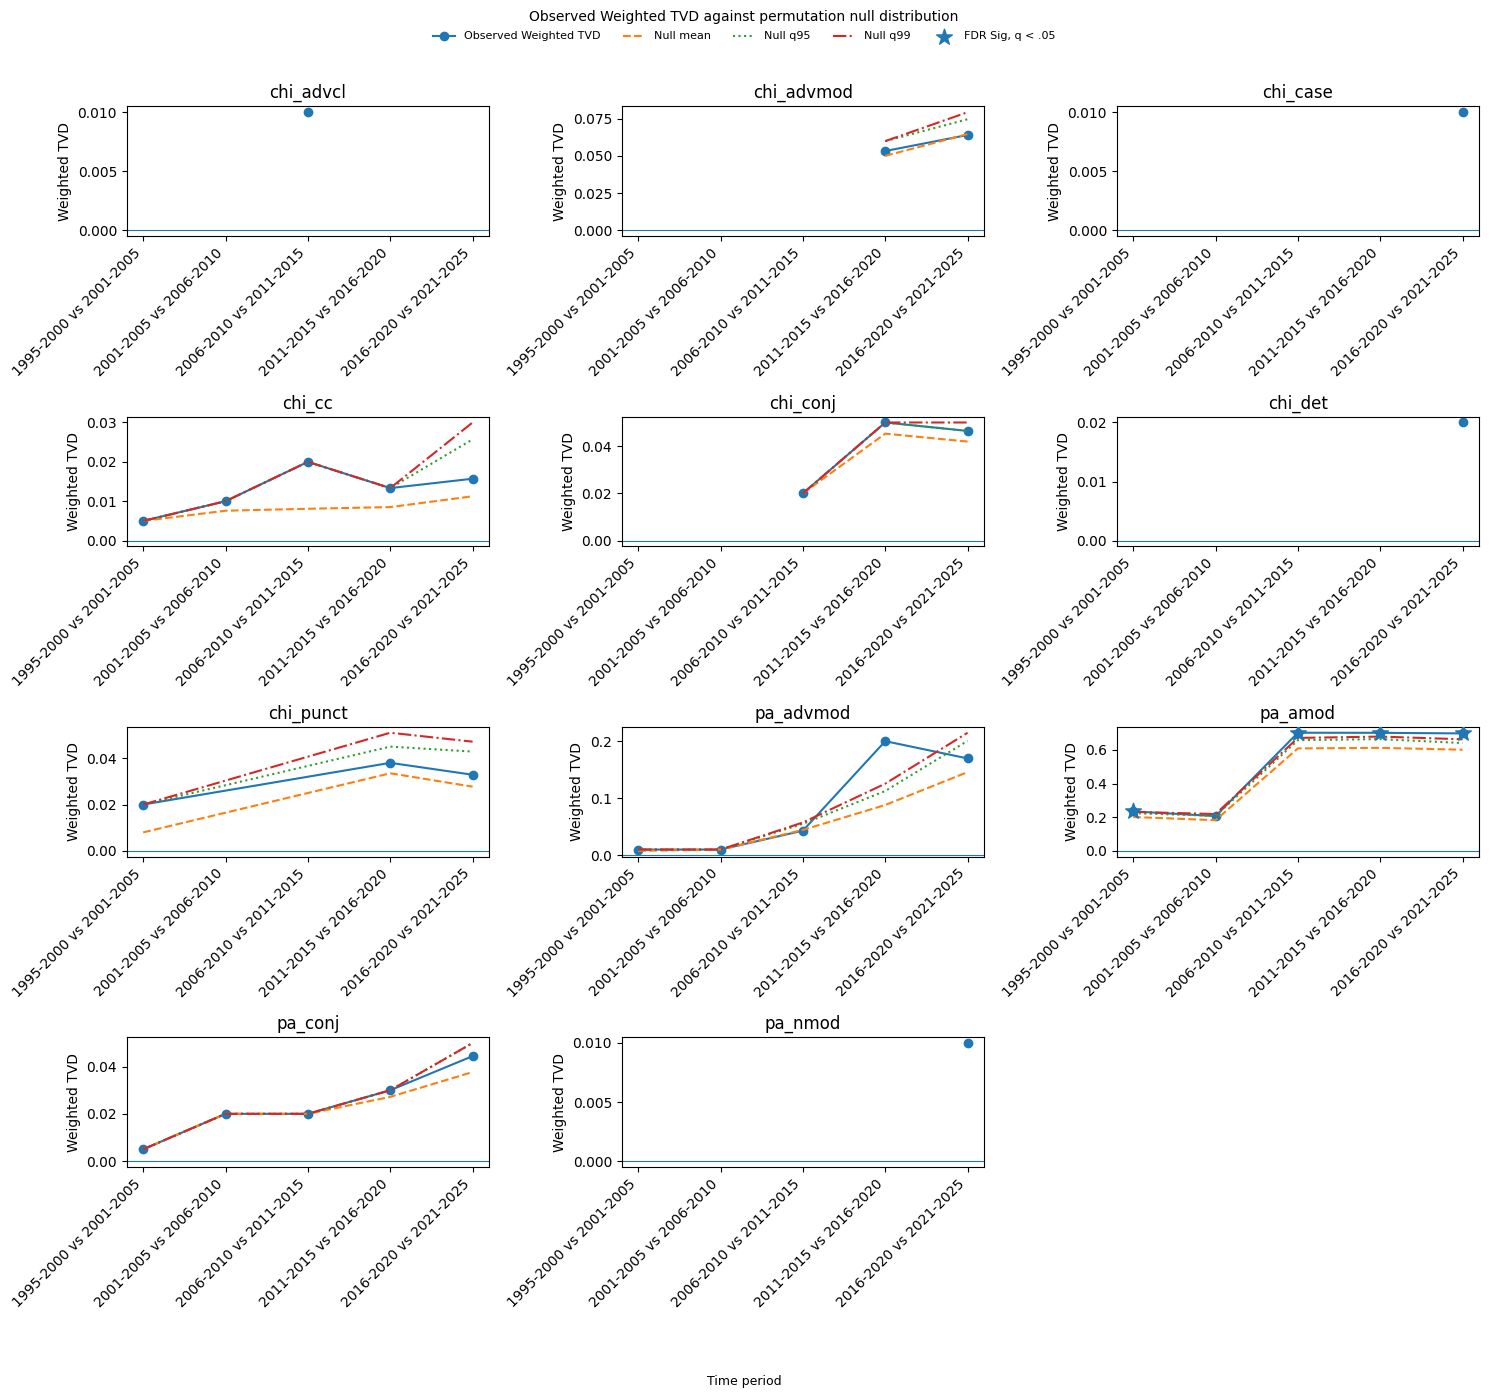

In [41]:
plot_permutation_test_consecutive_dist(perm_result_df)

In [45]:
perm_fdr_summary, corrected_slot_period_df = summarize_fdr_correction(perm_result_df)

perm_fdr_summary
# perm_fdr_summary.to_csv(rf"{output_SCD}/slot_type_perm_fdr_summary.csv", index=False)
perm_fdr_summary.to_csv(rf"{output_SCD}/sfiller_perm_fdr_summary.csv", index=False)
# corrected_slot_period_df

In [46]:
perm_fdr_summary

,slot,total_period_tests,valid_period_tests,invalid_period_tests,raw_p_significant,fdr_significant,corrected_by_fdr,raw_significant_percent,fdr_significant_percent,fdr_corrected_percent_of_raw_sig
0,chi_advcl,1,1,0,0,0,0,0.0,0.0,0.0
1,chi_advmod,2,2,0,0,0,0,0.0,0.0,0.0
2,chi_case,1,1,0,0,0,0,0.0,0.0,0.0
3,chi_cc,5,5,0,0,0,0,0.0,0.0,0.0
4,chi_conj,3,3,0,0,0,0,0.0,0.0,0.0
5,chi_det,1,1,0,0,0,0,0.0,0.0,0.0
6,chi_punct,3,3,0,0,0,0,0.0,0.0,0.0
7,pa_advmod,5,5,0,1,0,1,20.0,0.0,100.0
8,pa_amod,5,5,0,4,4,0,80.0,80.0,0.0
9,pa_conj,5,5,0,0,0,0,0.0,0.0,0.0


## Compute period x period distance matrix

In [47]:
period_period_dist_df = compute_period_period_dist(
    sfiller_df=sfiller_df,
    period_col="subfolder",
    # slot_col='pa_amod', # Required when the data contains multiple slot/feature types, otherwise set to None.
    min_freq=1,
    measure="tvd",
    mode="data_only",
    weighting=True,
    k=100,
)

fig = plot_period_period_dist(period_period_dist_df)
fig.show()

Computing period-period distribution distance with measure: tvd


ValueError: slot_col must be provided when the DataFrame contains 22 slot columns: ['pa_amod', 'chi_conj', 'pa_advmod', 'chi_punct', 'chi_cc', 'pa_conj', 'chi_case', 'chi_det', 'pa_obl', 'chi_advmod', 'chi_advcl', 'chi_nsubj', 'chi_cop', 'chi_obl', 'pa_parataxis', 'chi_appos', 'chi_parataxis', 'pa_appos', 'pa_nmod', 'pa_acl', 'chi_acl', 'pa_advcl'].

# Plot distance time-series

In [48]:
# Plot all slots on one big plot
# slots_to_plot = ['chi_case', 'chi_amod', 'pa_obl', 'chi_nmod', 'pa_nmod', 'pa_obj', 'chi_compound', 'pa_compound', 'pa_nsubj', 'chi_nsubj' ]  # Specify the slots you want to plot
# plot_all_dists_by_period(weighted_consecutive_dist_dict, layout='combined', slots=slots_to_plot)

# If not specify, plot everything
plot_all_dists_by_period(perm_result_df, layout="combined", col_to_plot="observed_statistic")

In [ ]:
# # Plot all slots on one big plot
# slots_to_plot = ['chi_acl', 'chi_acl:recl', 'chi_amod', 'chi_appos', 'pa_appos', 'chi_case', 'chi_compound', 'pa_compound', 'chi_conj', 'pa_conj', 'pa_iobj', 'chi_list', 'pa_list', 'chi_nmod', 'chi_nmod:desc', 'chi_nmod:poss', 'chi_nmod:unmarked', 'pa_nmod', 'pa_nmod:desc', 'pa_nmod:poss', 'pa_nmod:unmarked', 'pa_nsubj', 'chi_nummod', 'pa_nsubj:pass', 'pa_obl', 'pa_obl:agent', 'pa_obl:unmarked']  # Specify the slots you want to plot
# plot_all_dists_by_period(weighted_consecutive_dist, layout='combined', slots=slots_to_plot)

In [ ]:
# Alternative: Plot as subplots in a grid
# plot_timeseries_slots(consecutive_distance_dictionary, layout='subplots')

# Alternative: Plot each slot as a separate figure
# plot_timeseries_slots(consecutive_distance_dictionary, layout='separate')

# Save the plot to a file
# plot_timeseries_slots(consecutive_distance_dictionary, 
#                       layout='combined',
#                       save_path=f'{output_explorer}/timeseries_slots.png')